# IMPORT LIBRARIES AND CONFIG

In [1]:
import os, json, math, random, time, csv
import numpy as np
from pathlib import Path
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

import torch, torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, Subset
import timm

SEED = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device running on : {device}")

TRAIN_IMG_DIR = Path("../Datasets/train/images/")
TRAIN_LBL_DIR = Path("../Datasets/train/labels/")
TEST_IMG_DIR  = Path("../Datasets/test/images/")
OUTPUT_DIR    = Path("../Models");      OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SUBMIT_DIR    = Path("../Submission");  SUBMIT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_SUB    = Path("../Datasets/sample_submission.csv")

/home/diyrad167/.conda/envs/test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device running on : cuda


# LETTERBOX + ROBUST JSON COUNT

In [2]:
def letterbox_im(im: Image.Image, max_side: int, fill=0):
    w, h = im.size
    s = max_side / max(w, h)
    nw, nh = int(round(w*s)), int(round(h*s))
    im = im.resize((nw, nh), resample=Image.BICUBIC, reducing_gap=1.0)
    pad_w, pad_h = max_side - nw, max_side - nh
    pad_left  = pad_w // 2
    pad_top   = pad_h // 2
    pad_right = pad_w - pad_left
    pad_bottom= pad_h - pad_top
    return ImageOps.expand(im, border=(pad_left, pad_top, pad_right, pad_bottom), fill=fill)

def read_count_from_json(json_path: Path):
    with open(json_path, "r") as f:
        d = json.load(f)
    if isinstance(d, dict):
        if "human_num" in d and isinstance(d["human_num"], (int, float)):
            return float(d["human_num"])
        if "points" in d and isinstance(d["points"], list):
            return float(len(d["points"]))
    raise ValueError(f"Unexpected JSON format: {json_path}")

# DATASET

In [3]:
IM_SIZE     = 512

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class CrowdCountDataset(Dataset):
    def __init__(self, img_dir: Path, lbl_dir: Path, train=True, im_size=IM_SIZE):
        self.imgs = sorted([p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp"}])
        self.lbl_dir = lbl_dir
        self.train = train
        self.im_size = im_size

    def __len__(self): return len(self.imgs)

    def __getitem__(self, idx):
        p = self.imgs[idx]
        im = Image.open(p).convert("RGB")
        im = letterbox_im(im, max_side=self.im_size)

        if self.train:
            if random.random() < 0.5:
                im = ImageOps.mirror(im)
            if random.random() < 0.2:
                # tiny color jitters (don’t change counts)
                im = TF.adjust_brightness(im, 1.0 + random.uniform(-0.08, 0.08))
                im = TF.adjust_contrast(im,  1.0 + random.uniform(-0.08, 0.08))
                im = TF.adjust_saturation(im,1.0 + random.uniform(-0.08, 0.08))

        x = TF.to_tensor(im)
        x = TF.normalize(x, IMAGENET_MEAN, IMAGENET_STD)

        if self.train:
            y = read_count_from_json((self.lbl_dir / f"{p.stem}.json"))
            y = torch.tensor([y], dtype=torch.float32)
            return x, y, p.name
        else:
            return x, p.name


# DATALOADER'S AND SPLITTING: TRAIN AND VALIDATION

In [4]:
BATCH_SIZE  = 4
NUM_WORKERS = min(2, os.cpu_count() or 2)

tmp = CrowdCountDataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR, train=True, im_size=IM_SIZE)
counts = []
for p in tmp.imgs:
    with open(TRAIN_LBL_DIR / f"{p.stem}.json", "r") as f:
        d = json.load(f)
    counts.append(float(d["human_num"]) if "human_num" in d else float(len(d.get("points", []))))
counts = np.array(counts)

bins = np.digitize(counts, np.quantile(counts, [0.2,0.4,0.6,0.8]))
idx = np.arange(len(tmp))
val_ratio = 0.1
val_idx = []
for b in np.unique(bins):
    b_idx = idx[bins==b]
    k = max(1, int(round(len(b_idx)*val_ratio)))
    val_idx.extend(np.random.choice(b_idx, size=k, replace=False))
val_idx = np.array(sorted(set(val_idx)))
train_idx = np.array(sorted(list(set(idx) - set(val_idx))))

from torch.utils.data import Subset
ds_tr = Subset(tmp, train_idx.tolist())
ds_va = Subset(tmp, val_idx.tolist())

dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

len(ds_tr), len(ds_va)

(1710, 190)

# MODELLING: SWIN-TINY V1 REGRESSOR

In [5]:
CHANNELS_LAST = True

def build_swin_tiny_regressor(pretrained=True, freeze_to=2, use_checkpoint=True, img_size=IM_SIZE):
    backbone = timm.create_model(
        'swin_tiny_patch4_window7_224',
        pretrained=pretrained,
        num_classes=0,          # pooled features
        global_pool='avg',
        img_size=img_size,
        strict_img_size=False
    )
    if use_checkpoint and hasattr(backbone, "set_grad_checkpointing"):
        backbone.set_grad_checkpointing(True)

    head = nn.Sequential(
        nn.LayerNorm(backbone.num_features),
        nn.Linear(backbone.num_features, 512),
        nn.GELU(),
        nn.Dropout(0.2),
        nn.Linear(512, 1)
    )
    model = nn.Sequential(backbone, head)

    # freeze early stages if desired (stabilize + VRAM)
    try:
        layers = backbone.layers
        for li, layer in enumerate(layers):
            if li <= freeze_to - 1:
                for p in layer.parameters():
                    p.requires_grad = False
        if freeze_to > 0:
            for _, p in backbone.patch_embed.named_parameters():
                p.requires_grad = False
            if hasattr(backbone, "pos_drop"):
                for p in backbone.pos_drop.parameters():
                    p.requires_grad = False
    except Exception:
        for name, p in backbone.named_parameters():
            if any(name.startswith(k) for k in ("patch_embed", "pos_drop", "layers.0", "layers.1")):
                p.requires_grad = False

    return model

model = build_swin_tiny_regressor(pretrained=True, freeze_to=2, use_checkpoint=True, img_size=IM_SIZE).to(device)
if CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

loss_fn = nn.SmoothL1Loss(beta=2.0)

@torch.no_grad()
def mae(pred, target):
    return (pred.squeeze(1) - target.squeeze(1)).abs().mean().item()

# SETUP OPTIMIZER'S, SCHEDULER, AND SCALER

In [6]:
ACC_STEPS   = 1
LR          = 1e-4
WD          = 5e-2
EPOCHS      = 30
WARMUP_EPOCHS = 3
GRAD_CLIP   = 1.0

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

def lr_at(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch+1)/WARMUP_EPOCHS
    t = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5*(1+math.cos(math.pi*t))

sched  = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lr_at)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))

/tmp/ipykernel_41017/56220650.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))


# TRAINING LOOP

In [7]:
BEST_PATH = OUTPUT_DIR / f"best_swinT_{IM_SIZE}_ep30_lr1e4_wd5e2.pth"
history = {'tr_loss': [], 'tr_mae': [], 'va_loss': [], 'va_mae': [], 'lr': []}
best_mae = float('inf'); patience=10; bad_epochs=0

for epoch in range(EPOCHS):
    t0=time.time()
    model.train()
    tr_loss=tr_mae=0.0; n_tr=0
    opt.zero_grad(set_to_none=True)

    for step,(x,y,_) in enumerate(dl_tr):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            pred = model(x)
            loss = loss_fn(pred, y) / ACC_STEPS

        scaler.scale(loss).backward()

        if (step+1) % ACC_STEPS == 0:
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(opt); scaler.update()
            opt.zero_grad(set_to_none=True)

        # logging (use unscaled)
        tr_loss += (loss.item()*ACC_STEPS)*x.size(0)
        tr_mae  += (pred.detach()-y).abs().sum().item()
        n_tr    += x.size(0)

    # flush remainder if steps not divisible by ACC_STEPS
    if (step+1) % ACC_STEPS != 0:
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(opt); scaler.update()
        opt.zero_grad(set_to_none=True)

    tr_loss/=n_tr; tr_mae/=n_tr

    model.eval(); va_loss=va_mae=0.0; n_va=0
    with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
        for x,y,_ in dl_va:
            x = x.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
            pred = model(x); loss = loss_fn(pred, y)
            va_loss += loss.item()*x.size(0)
            va_mae  += (pred-y).abs().sum().item()
            n_va    += x.size(0)

    va_loss/=n_va; va_mae/=n_va
    sched.step()

    history['tr_loss'].append(tr_loss); history['tr_mae'].append(tr_mae)
    history['va_loss'].append(va_loss); history['va_mae'].append(va_mae)
    history['lr'].append(sched.get_last_lr()[0])

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train L {tr_loss:.4f} MAE {tr_mae:.2f} | "
          f"Val L {va_loss:.4f} MAE {va_mae:.2f} | "
          f"LR {sched.get_last_lr()[0]:.2e} | {time.time()-t0:.1f}s")

    if va_mae < best_mae - 1e-6:
        best_mae, bad_epochs = va_mae, 0
        torch.save({"model": model.state_dict()}, BEST_PATH)
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping."); break

print("Best val MAE:", best_mae, "| saved:", BEST_PATH)

/tmp/ipykernel_41017/2626202272.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
/home/diyrad167/.conda/envs/test/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/diyrad167/.conda/envs/test/lib/python3.10/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/tmp/ipykernel_41017/2626202272.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is

Epoch 01/30 | Train L 123.0729 MAE 124.00 | Val L 100.2181 MAE 101.12 | LR 6.67e-05 | 100.2s
Epoch 02/30 | Train L 97.9051 MAE 98.83 | Val L 69.3441 MAE 70.27 | LR 1.00e-04 | 102.1s
Epoch 03/30 | Train L 78.1256 MAE 79.07 | Val L 55.6281 MAE 56.55 | LR 1.00e-04 | 102.9s
Epoch 04/30 | Train L 65.0700 MAE 65.99 | Val L 46.5840 MAE 47.48 | LR 9.97e-05 | 103.4s
Epoch 05/30 | Train L 58.0560 MAE 58.98 | Val L 39.7800 MAE 40.71 | LR 9.87e-05 | 103.8s
Epoch 06/30 | Train L 53.0249 MAE 53.94 | Val L 33.6668 MAE 34.58 | LR 9.70e-05 | 103.7s
Epoch 07/30 | Train L 48.9617 MAE 49.88 | Val L 27.4028 MAE 28.32 | LR 9.47e-05 | 103.7s
Epoch 08/30 | Train L 45.2232 MAE 46.13 | Val L 26.7876 MAE 27.68 | LR 9.18e-05 | 104.2s
Epoch 09/30 | Train L 43.1010 MAE 44.00 | Val L 32.1179 MAE 33.01 | LR 8.83e-05 | 104.2s
Epoch 10/30 | Train L 40.2748 MAE 41.18 | Val L 25.4184 MAE 26.31 | LR 8.43e-05 | 104.1s
Epoch 11/30 | Train L 37.8039 MAE 38.69 | Val L 28.0980 MAE 28.97 | LR 7.99e-05 | 104.4s
Epoch 12/30 | Tra

# SEE THE RESULTS FROM EACH EPOCHS

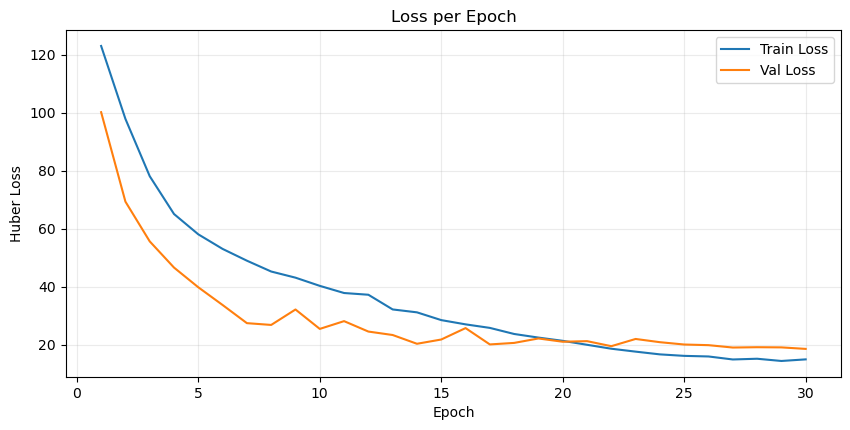

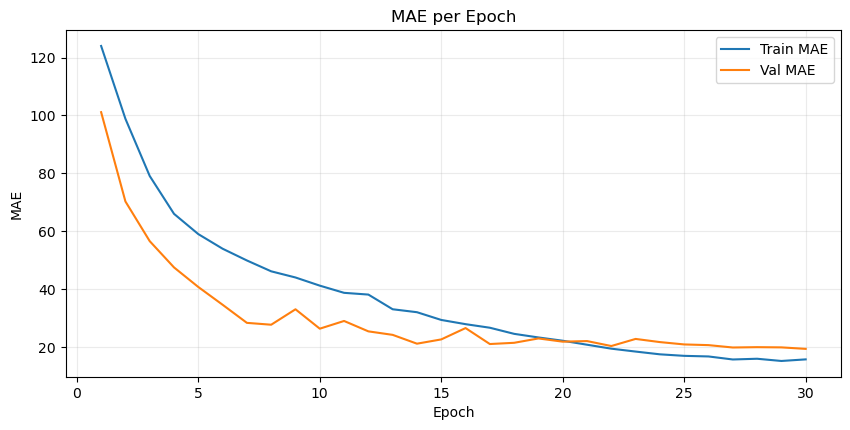

In [8]:
epochs = range(1, len(history['tr_loss'])+1)

plt.figure(figsize=(10,4.5))
plt.plot(epochs, history['tr_loss'], label='Train Loss')
plt.plot(epochs, history['va_loss'],   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Huber Loss'); plt.title('Loss per Epoch'); plt.grid(True, alpha=.25); plt.legend()
plt.show()

plt.figure(figsize=(10,4.5))
plt.plot(epochs, history['tr_mae'], label='Train MAE')
plt.plot(epochs, history['va_mae'], label='Val MAE')
plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.title('MAE per Epoch'); plt.grid(True, alpha=.25); plt.legend()
plt.show()

/tmp/ipykernel_41017/3983737406.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


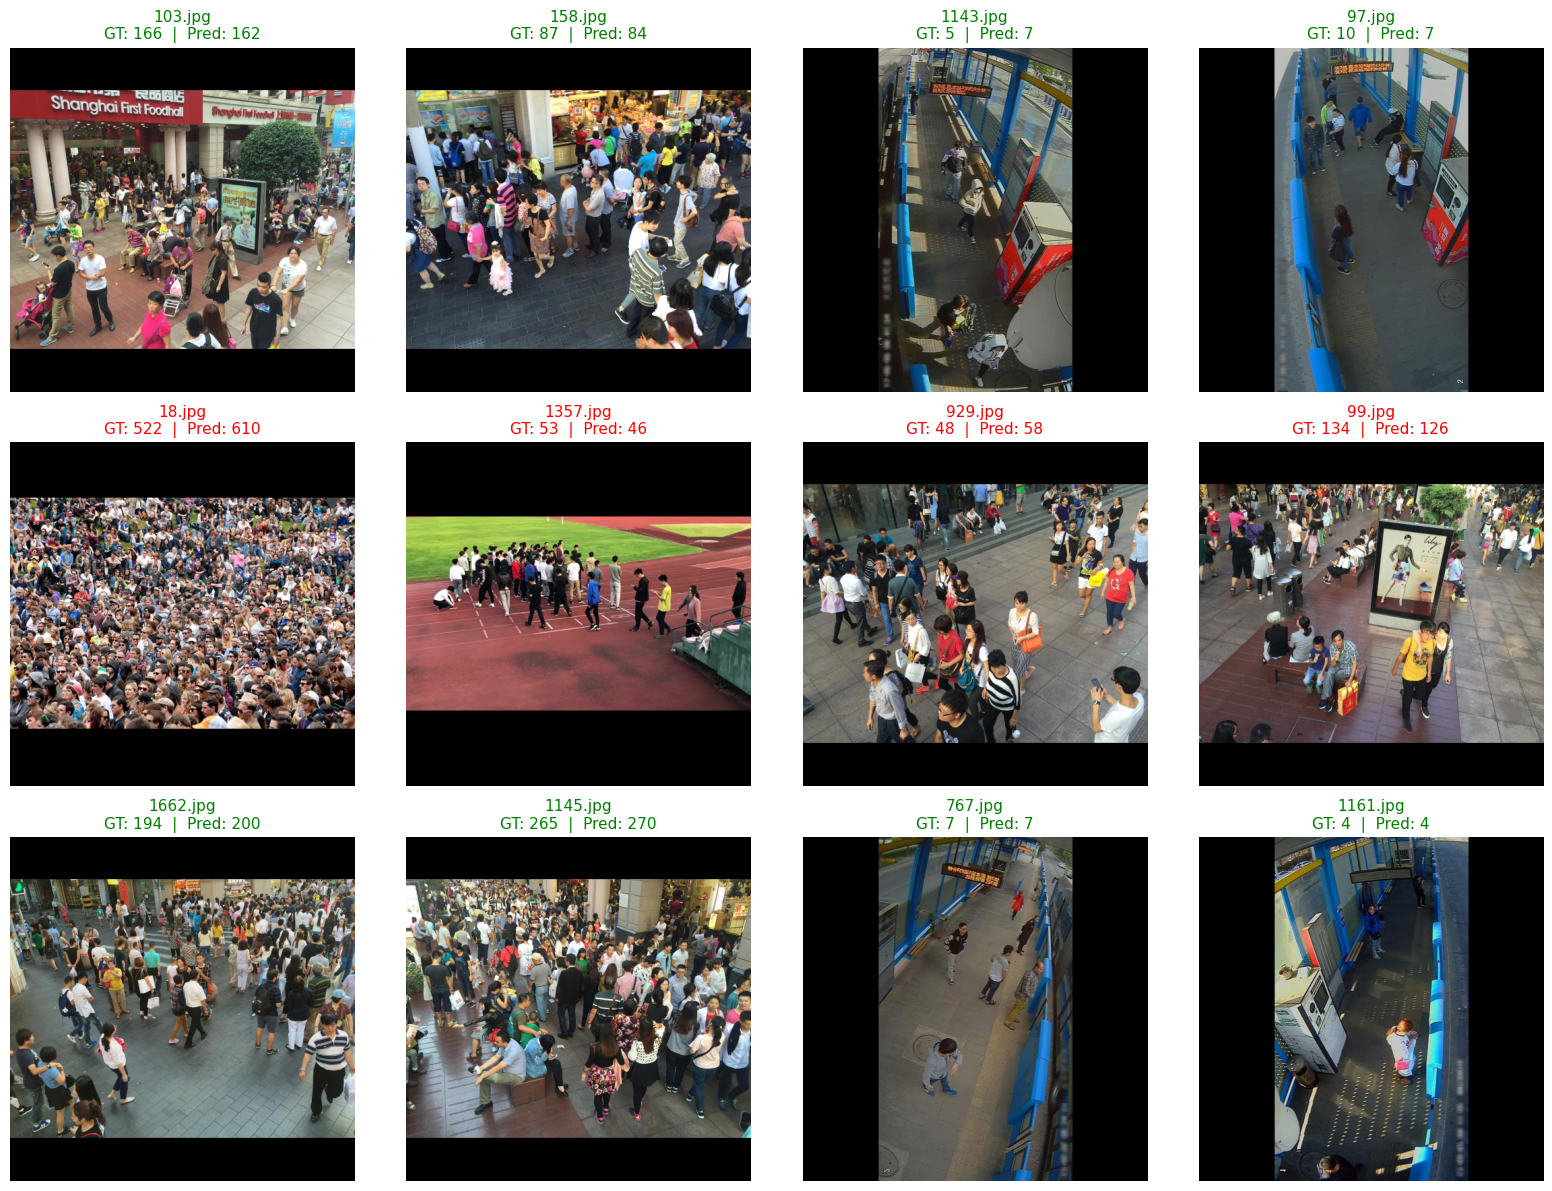

In [9]:
model.eval()

# --- helpers
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(device)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(device)

def denorm(img_t: torch.Tensor):
    """img_t: (3,H,W) normalized tensor on any device -> (H,W,3) numpy [0,1]"""
    if img_t.device != IMAGENET_MEAN.device:
        mean, std = IMAGENET_MEAN.cpu(), IMAGENET_STD.cpu()
    else:
        mean, std = IMAGENET_MEAN, IMAGENET_STD
    x = img_t * std + mean
    x = x.clamp(0,1).permute(1,2,0).detach().cpu().numpy()
    return x

def good_color(pred, gt):
    # "close" if absolute error <= max(5 people, 5% of GT)
    thr = max(5.0, 0.05 * float(gt))
    return 'green' if abs(float(pred) - float(gt)) <= thr else 'red'

# --- pick 12 random indices from the validation subset
NROWS, NCOLS = 3, 4
nsamples = NROWS * NCOLS
val_indices = list(range(len(ds_va)))
random.shuffle(val_indices)
val_indices = val_indices[:nsamples]

# --- run prediction in small batches (VRAM-friendly)
xs, gts, names = [], [], []
for i in val_indices:
    x, y, name = ds_va[i]  # ds_va is a Subset of the training dataset
    xs.append(x.unsqueeze(0))
    gts.append(float(y.item()))
    names.append(name)

# batch predict
with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
    # cat might be large; do micro-batches
    preds = []
    micro = 4
    for s in range(0, len(xs), micro):
        bx = torch.cat(xs[s:s+micro], dim=0)
        if CHANNELS_LAST:
            bx = bx.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            bx = bx.to(device, non_blocking=True)
        by = model(bx).squeeze(1).float().detach().cpu().numpy()
        preds.extend(by.tolist())
preds = [max(0.0, p) for p in preds]  # clip to non-negative

# --- plot grid
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(16, 12))
axes = axes.flatten()

for ax, x, gt, pr, name in zip(axes, xs, gts, preds, names):
    # plt.title("Restnet 34 LR 0.003 WD 0.0001 AdamW")
    img = denorm(x.squeeze(0).to(device if next(model.parameters()).is_cuda else 'cpu'))
    ax.imshow(img)
    ax.axis('off')
    color = good_color(pr, gt)
    ax.set_title(f"{name}\nGT: {int(round(gt))}  |  Pred: {int(round(pr))}", color=color, fontsize=11)

plt.tight_layout()
plt.show()

# LOAD BEST MODEL AND SANITY CHECK ON VALIDATION

In [10]:
ckpt = torch.load(BEST_PATH, map_location="cpu")
model.load_state_dict(ckpt["model"])
model.to(device)
if CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)
model.eval()

# 1) Build a *serial* (single-process) val loader to avoid multiprocessing issues
#    We reuse ds_va (Subset), but disable workers and pinning for this quick check.
va_loader_clean = DataLoader(
    ds_va, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=False, drop_last=False
)

# 2) Optional: clear and sync before/after to flush any async CUDA error
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

# 3) Run evaluation with the same memory_format you used in training
va_mae, n_va = 0.0, 0
with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
    for x, y, _ in va_loader_clean:
        if CHANNELS_LAST:
            x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        pred = model(x)
        va_mae += (pred - y).abs().sum().item()
        n_va   += x.size(0)

# 4) Final sync + print
if torch.cuda.is_available():
    torch.cuda.synchronize()

print(f"Validation MAE: {va_mae / max(1, n_va):.2f}")

/tmp/ipykernel_41017/1118871566.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


Validation MAE: 20.00


# TEST DATASET AND PRED

In [12]:
if IM_SIZE % 28 != 0:
    print(f"[Warning] IM_SIZE={IM_SIZE} is not divisible by 28. "
          f"Swin will still run since strict_img_size=False, "
          f"but window padding may occur.")

# 1) Rebuild a *serial* test loader (no workers) to avoid CUDA multiprocessing issues
class CrowdTestDataset(Dataset):
    def __init__(self, img_dir: Path):
        self.imgs = sorted([p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp"}])
    def __len__(self): return len(self.imgs)
    def __getitem__(self, idx):
        p = self.imgs[idx]
        im = Image.open(p).convert("RGB")
        im = letterbox_im(im, max_side=IM_SIZE)  # Same preprocessing as train/val
        x = TF.to_tensor(im)
        x = TF.normalize(x, IMAGENET_MEAN, IMAGENET_STD)
        return x, p.name

ds_te = CrowdTestDataset(TEST_IMG_DIR)

# Smaller batch + single-process loader tends to be the most stable on tight VRAM
BATCH_SIZE_TEST = 2
dl_te_clean = DataLoader(
    ds_te, batch_size=BATCH_SIZE_TEST, shuffle=False,
    num_workers=0, pin_memory=False, drop_last=False
)

# 2) Ensure model is on device and memory_format matches training
model.to(device)
if CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)
model.eval()

# 3) Extra hygiene around CUDA state
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

pred_rows = []
err = None

try:
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
        for x, names in dl_te_clean:
            if CHANNELS_LAST:
                x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
            else:
                x = x.to(device, non_blocking=True)

            yhat = model(x).squeeze(1).float().detach().cpu().numpy()
            yhat = np.clip(yhat, 0, None)  # counts >= 0

            for name, pred in zip(names, yhat):
                pred_rows.append((name, float(pred)))

    if torch.cuda.is_available():
        torch.cuda.synchronize()

except RuntimeError as e:
    err = e

if err is not None:
    # If we land here, the CUDA context was likely poisoned earlier.
    # The only guaranteed remedy is a kernel/runtime restart.
    raise RuntimeError(
        "CUDA evaluation failed (likely due to a prior device-side error). "
        "Please restart the kernel and re-run with the fixed Swin settings "
        "(IM_SIZE multiple of 28 and strict_img_size=False)."
    ) from err

# 4) Write submission (preserve sample order if provided)
sample_csv = Path("../Submission/512sub_swinT_30ep_adamw_wd005_lr000001.csv")  # adjust if needed
if sample_csv.exists():
    import pandas as pd
    sub = pd.read_csv(sample_csv)
    key, outcol = sub.columns[:2]
    pred_map = {k: v for k, v in pred_rows}
    sub[outcol] = sub[key].map(lambda k: round(pred_map.get(k, 0.0)))
    out_path = OUTPUT_DIR / "512sub_swinT_30ep_adamw_wd005_lr000001.csv"
    sub.to_csv(out_path, index=False)
else:
    out_path = OUTPUT_DIR / "512sub_swinT_30ep_adamw_wd005_lr000001.csv"
    with open(out_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["image_id", "count"])
        for k, v in pred_rows:
            w.writerow([k, round(v)])

print("Wrote:", out_path)


[Warning] IM_SIZE=512 is not divisible by 28. Swin will still run since strict_img_size=False, but window padding may occur.


/tmp/ipykernel_41017/2165981490.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


Wrote: ../Models/512sub_swinT_30ep_adamw_wd005_lr000001.csv
